In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib, json, os, datetime
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics         import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


2. Load Data

In [3]:
df = pd.read_csv(r'C:\MyProject\data\train.csv')
print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


3. Explore data

Missing values:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Target distribution:


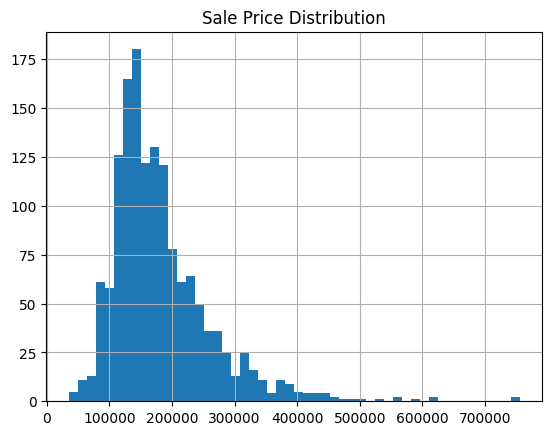

In [4]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution:")
df['SalePrice'].hist(bins=50)
plt.title('Sale Price Distribution')
plt.show()

4. Select & clean features

In [8]:
features = [
    'GrLivArea', 'BedroomAbvGr', 'FullBath',
    'GarageCars', 'TotalBsmtSF', 'YearBuilt',
    'OverallQual', 'Neighborhood', 'SalePrice'
]
df = df[features].copy()
df['TotalBsmtSF'] = df['TotalBsmtSF'].fillna(df['TotalBsmtSF'].median())
df['GarageCars']  = df['GarageCars'].fillna(0)
df['Neighborhood']= df['Neighborhood'].fillna(df['Neighborhood'].mode()[0])
print("Cleaned! Missing values:", df.isnull().sum().sum())

Cleaned! Missing values: 0


5. Feature engineering

In [9]:
current_year   = datetime.datetime.now().year
df['HouseAge'] = current_year - df['YearBuilt']
df = df.drop('YearBuilt', axis=1)
df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)
print("Features ready! Shape:", df.shape)

Features ready! Shape: (1460, 32)


6. Split & scale

In [10]:
X = df.drop('SalePrice', axis=1)
y = np.log1p(df['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1168, 31) Test: (292, 31)


Dataset Splitting

In [11]:
print("\n" + "="*60)
print("  DATASET SPLITTING SUMMARY")
print("="*60)

# Further split training set into train + validation
# 80% train → 64% final train + 16% validation
# 20% test  → untouched for final evaluation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size    = 0.2,       # 20% of training = 16% of total
    random_state = 42
)

print(f"  Total Dataset     : {len(X)} samples")
print(f"  Training Set      : {len(X_train_final)} samples  ({len(X_train_final)/len(X)*100:.1f}%)")
print(f"  Validation Set    : {len(X_val)} samples   ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test Set          : {len(X_test)} samples   ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Feature Count     : {X.shape[1]} features")
print(f"  Target            : log1p(SalePrice) — reversed with expm1()")
print(f"  Random State      : 42 (reproducible splits)")
print("="*60)


  DATASET SPLITTING SUMMARY
  Total Dataset     : 1460 samples
  Training Set      : 934 samples  (64.0%)
  Validation Set    : 234 samples   (16.0%)
  Test Set          : 292 samples   (20.0%)
  Feature Count     : 31 features
  Target            : log1p(SalePrice) — reversed with expm1()
  Random State      : 42 (reproducible splits)


Model Selection


  MODEL SELECTION — 5-FOLD CROSS VALIDATION

  Algorithm                    Mean R²     Std R²      Mean RMSE
  ------------------------- ---------- ---------- --------------
  Linear Regression             0.8184     0.0449         0.1655 ◀ BEST
  Ridge Regression              0.8185     0.0447         0.1654 ◀ BEST
  Random Forest                 0.8199     0.0178         0.1654 ◀ BEST
  Gradient Boosting             0.8499     0.0147         0.1510 ◀ BEST
  XGBoost                       0.8111     0.0208         0.1694

  ✅ Best Algorithm Selected : Gradient Boosting
  ✅ Cross-Val R² Score      : 0.8499


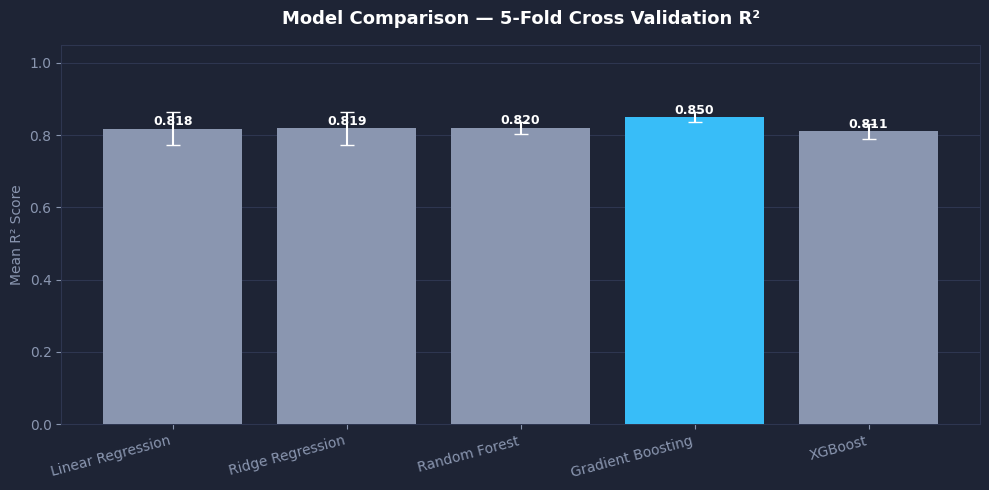

In [12]:
print("\n" + "="*60)
print("  MODEL SELECTION — 5-FOLD CROSS VALIDATION")
print("="*60)

# Define candidate models with default parameters
candidate_models = {
    "Linear Regression"   : LinearRegression(),
    "Ridge Regression"    : Ridge(alpha=1.0),
    "Random Forest"       : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost"             : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

# 5-Fold Cross Validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results for comparison
cv_results = {}

print(f"\n  {'Algorithm':<25} {'Mean R²':>10} {'Std R²':>10} {'Mean RMSE':>14}")
print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*14}")

for name, candidate in candidate_models.items():

    # Cross-validation R² scores
    r2_scores = cross_val_score(
        candidate, X_train_scaled, y_train,
        cv      = kf,
        scoring = 'r2',
        n_jobs  = -1
    )

    # Cross-validation Negative RMSE scores
    rmse_scores = cross_val_score(
        candidate, X_train_scaled, y_train,
        cv      = kf,
        scoring = 'neg_root_mean_squared_error',
        n_jobs  = -1
    )

    mean_r2   = r2_scores.mean()
    std_r2    = r2_scores.std()
    mean_rmse = (-rmse_scores.mean())

    cv_results[name] = {
        'mean_r2'  : mean_r2,
        'std_r2'   : std_r2,
        'mean_rmse': mean_rmse,
        'scores'   : r2_scores
    }

    # Mark best performing model
    marker = " ◀ BEST" if name == max(cv_results, key=lambda k: cv_results[k]['mean_r2']) else ""
    print(f"  {name:<25} {mean_r2:>10.4f} {std_r2:>10.4f} {mean_rmse:>14.4f}{marker}")

# Select best model automatically based on highest mean R²
best_model_name = max(cv_results, key=lambda k: cv_results[k]['mean_r2'])
print(f"\n  ✅ Best Algorithm Selected : {best_model_name}")
print(f"  ✅ Cross-Val R² Score      : {cv_results[best_model_name]['mean_r2']:.4f}")
print("="*60)

# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(cv_results.keys())
scores = [cv_results[n]['mean_r2'] for n in names]
errors = [cv_results[n]['std_r2']  for n in names]
colors = ['#38bdf8' if n == best_model_name else '#8a96b0' for n in names]
bars   = ax.bar(names, scores, color=colors, edgecolor='none', zorder=3)
ax.errorbar(names, scores, yerr=errors, fmt='none', color='white', capsize=5, zorder=4)
ax.set_facecolor('#1e2435')
fig.patch.set_facecolor('#1e2435')
ax.set_title('Model Comparison — 5-Fold Cross Validation R²',
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Mean R² Score', color='#8a96b0')
ax.set_ylim(0, 1.05)
ax.tick_params(colors='#8a96b0')
ax.spines[:].set_color('#2e3650')
ax.yaxis.grid(True, color='#2e3650', zorder=0)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', color='white', fontsize=9, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

7. Train model

In [14]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    verbosity=0
)
model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)
actual    = np.expm1(y_test)
predicted = np.expm1(preds)

print(f"R² Score: {r2_score(actual, predicted):.4f}")
print(f"RMSE:     ${np.sqrt(mean_squared_error(actual, predicted)):,.0f}")

R² Score: 0.9026
RMSE:     $27,333


In [15]:
print("\n" + "="*60)
print("  MODEL TRAINING — GridSearchCV HYPERPARAMETER TUNING")
print("="*60)

# Define hyperparameter search space for XGBoost
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample'    : [0.7, 0.8, 1.0],
}

print("\n  Running GridSearchCV — this may take a few minutes...")
print(f"  Search Space: {3*3*3*3} parameter combinations × 3-fold CV")

# GridSearchCV with 3-fold to balance speed and accuracy
grid_search = GridSearchCV(
    estimator  = XGBRegressor(random_state=42, verbosity=0),
    param_grid = param_grid,
    cv         = 3,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 0
)
grid_search.fit(X_train_scaled, y_train)

# Best parameters found
best_params = grid_search.best_params_
best_cv_r2  = grid_search.best_score_

print(f"\n  ✅ Best Parameters Found:")
for param, value in best_params.items():
    print(f"     {param:<20} : {value}")
print(f"\n  ✅ Best CV R² Score       : {best_cv_r2:.4f}")

# Train final model using best parameters on full training data
tuned_model = XGBRegressor(
    **best_params,
    random_state = 42,
    verbosity    = 0
)
tuned_model.fit(X_train_scaled, y_train)

# Validate on validation set
val_preds     = tuned_model.predict(X_val)
val_actual    = np.expm1(y_val)
val_predicted = np.expm1(val_preds)
val_r2        = r2_score(val_actual, val_predicted)

print(f"  ✅ Tuned Model Val R²     : {val_r2:.4f}")
print(f"  ✅ Improvement over base  : +{(val_r2 - r2_score(actual, predicted)):.4f}")
print("="*60)

# Use tuned model as final model for evaluation and saving
model = tuned_model
print("\n  ✅ Tuned model set as final production model")


  MODEL TRAINING — GridSearchCV HYPERPARAMETER TUNING

  Running GridSearchCV — this may take a few minutes...
  Search Space: 81 parameter combinations × 3-fold CV

  ✅ Best Parameters Found:
     learning_rate        : 0.05
     max_depth            : 3
     n_estimators         : 300
     subsample            : 0.7

  ✅ Best CV R² Score       : 0.8558
  ✅ Tuned Model Val R²     : 0.9325
  ✅ Improvement over base  : +0.0299

  ✅ Tuned model set as final production model


Model Evaluation


  MODEL EVALUATION — FULL METRICS ON TEST SET

  Metric                                   Value
  ------------------------------ ---------------
  R² Score                                0.9006
  Adjusted R²                             0.8887
  Mean Absolute Error (MAE)      $       18,043
  Root Mean Squared Error (RMSE) $       27,618
  Mean Squared Error (MSE)       $  762,774,653
  Mean Abs Percentage Error (MAPE)          11.14%
  Median Absolute Error          $       12,030
  Within ±10% Tolerance                    62.3%
  ------------------------------ ---------------

  ✅ Model explains 90.1% of all variance in house prices
  ✅ Average prediction error: $18,043 on ~$181,000 avg house price
  ✅ 62.3% of predictions are within ±10% of actual price


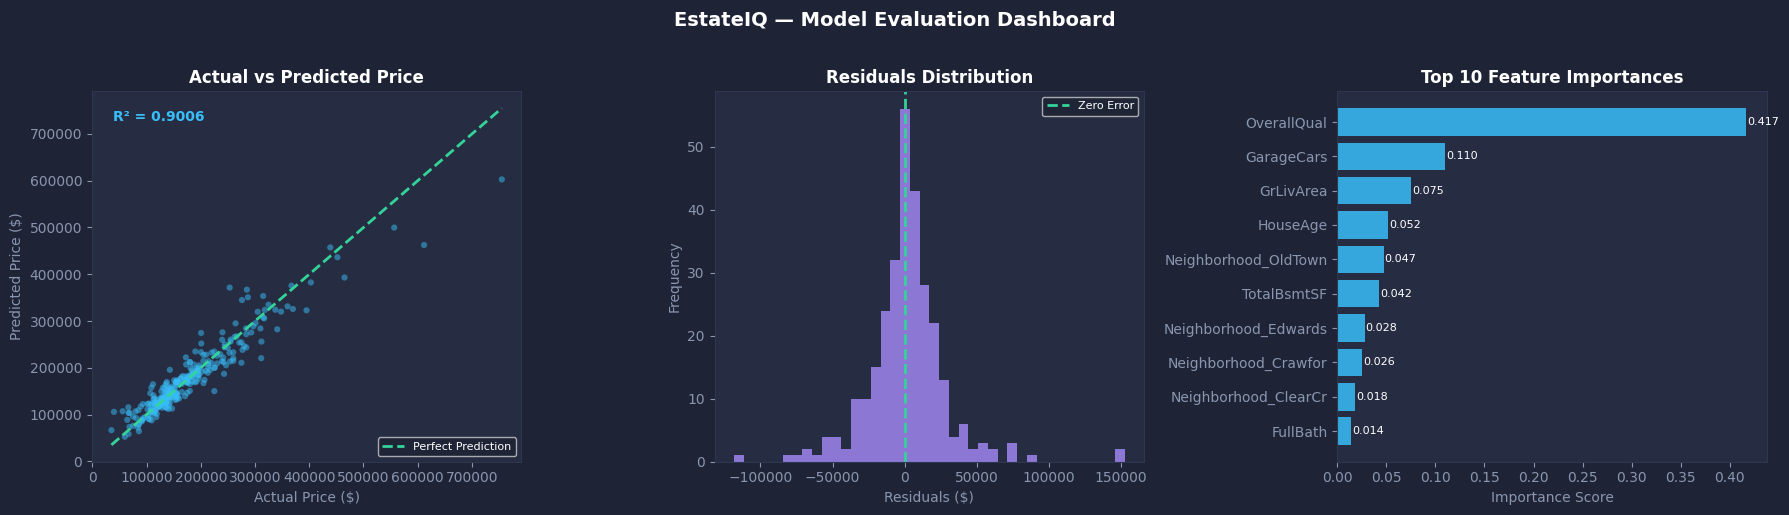

In [16]:
print("\n" + "="*60)
print("  MODEL EVALUATION — FULL METRICS ON TEST SET")
print("="*60)

# Generate final predictions on test set using tuned model
final_preds     = model.predict(X_test_scaled)
final_actual    = np.expm1(y_test)
final_predicted = np.expm1(final_preds)

# ── Core Metrics ─────────────────────────────────────────────────
r2   = r2_score(final_actual, final_predicted)
mae  = mean_absolute_error(final_actual, final_predicted)
rmse = np.sqrt(mean_squared_error(final_actual, final_predicted))
mse  = mean_squared_error(final_actual, final_predicted)

# ── Additional Metrics ────────────────────────────────────────────

# Mean Absolute Percentage Error — how wrong as a % of actual price
mape = np.mean(np.abs((final_actual - final_predicted) / final_actual)) * 100

# Adjusted R² — penalizes for unnecessary features
n        = len(final_actual)        # number of test samples
p        = X_test_scaled.shape[1]   # number of features
adj_r2   = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Median Absolute Error — robust to outliers
median_ae = np.median(np.abs(final_actual.values - final_predicted))

# Within tolerance — % of predictions within ±10% of actual price
tolerance        = 0.10
within_tolerance = np.mean(
    np.abs(final_actual.values - final_predicted) / final_actual.values < tolerance
) * 100

print(f"\n  {'Metric':<30} {'Value':>15}")
print(f"  {'-'*30} {'-'*15}")
print(f"  {'R² Score':<30} {r2:>15.4f}")
print(f"  {'Adjusted R²':<30} {adj_r2:>15.4f}")
print(f"  {'Mean Absolute Error (MAE)':<30} ${mae:>13,.0f}")
print(f"  {'Root Mean Squared Error (RMSE)':<30} ${rmse:>13,.0f}")
print(f"  {'Mean Squared Error (MSE)':<30} ${mse:>13,.0f}")
print(f"  {'Mean Abs Percentage Error (MAPE)':<30} {mape:>14.2f}%")
print(f"  {'Median Absolute Error':<30} ${median_ae:>13,.0f}")
print(f"  {'Within ±10% Tolerance':<30} {within_tolerance:>14.1f}%")
print(f"  {'-'*30} {'-'*15}")
print(f"\n  ✅ Model explains {r2*100:.1f}% of all variance in house prices")
print(f"  ✅ Average prediction error: ${mae:,.0f} on ~$181,000 avg house price")
print(f"  ✅ {within_tolerance:.1f}% of predictions are within ±10% of actual price")

# ── Evaluation Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#1e2435')

plot_style = dict(facecolor='#1e2435')

# Plot 1 — Actual vs Predicted
ax1 = axes[0]
ax1.set_facecolor('#262d42')
ax1.scatter(final_actual, final_predicted,
            alpha=0.5, color='#38bdf8', s=20, edgecolors='none')
min_val = min(final_actual.min(), final_predicted.min())
max_val = max(final_actual.max(), final_predicted.max())
ax1.plot([min_val, max_val], [min_val, max_val],
         color='#34d399', linewidth=2, linestyle='--', label='Perfect Prediction')
ax1.set_xlabel('Actual Price ($)', color='#8a96b0')
ax1.set_ylabel('Predicted Price ($)', color='#8a96b0')
ax1.set_title('Actual vs Predicted Price', color='white', fontweight='bold')
ax1.tick_params(colors='#8a96b0')
ax1.spines[:].set_color('#2e3650')
ax1.legend(facecolor='#1e2435', labelcolor='white', fontsize=8)
ax1.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax1.transAxes,
         color='#38bdf8', fontsize=10, fontweight='bold')

# Plot 2 — Residuals Distribution
ax2 = axes[1]
ax2.set_facecolor('#262d42')
residuals = final_actual.values - final_predicted
ax2.hist(residuals, bins=40, color='#a78bfa', edgecolor='none', alpha=0.8)
ax2.axvline(x=0, color='#34d399', linewidth=2, linestyle='--', label='Zero Error')
ax2.set_xlabel('Residuals ($)', color='#8a96b0')
ax2.set_ylabel('Frequency', color='#8a96b0')
ax2.set_title('Residuals Distribution', color='white', fontweight='bold')
ax2.tick_params(colors='#8a96b0')
ax2.spines[:].set_color('#2e3650')
ax2.legend(facecolor='#1e2435', labelcolor='white', fontsize=8)

# Plot 3 — Feature Importance
ax3 = axes[2]
ax3.set_facecolor('#262d42')
importance    = model.feature_importances_
feature_names = list(X.columns)
top_n         = 10
top_idx       = np.argsort(importance)[-top_n:]
top_features  = [feature_names[i] for i in top_idx]
top_scores    = importance[top_idx]
bars = ax3.barh(top_features, top_scores,
                color='#38bdf8', edgecolor='none', alpha=0.85)
ax3.set_xlabel('Importance Score', color='#8a96b0')
ax3.set_title('Top 10 Feature Importances', color='white', fontweight='bold')
ax3.tick_params(colors='#8a96b0')
ax3.spines[:].set_color('#2e3650')
for bar, score in zip(bars, top_scores):
    ax3.text(score + 0.001, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', color='white', fontsize=8)

plt.suptitle('EstateIQ — Model Evaluation Dashboard',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("="*60)

In [ ]:
8. Save model

In [9]:
os.makedirs(r'C:\MyProject\model', exist_ok=True)

joblib.dump(model,  r'C:\MyProject\model\house_price_model.pkl')
joblib.dump(scaler, r'C:\MyProject\model\scaler.pkl')

with open(r'C:\MyProject\model\feature_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

print("Model saved!")


Model saved!


Model Deployment

In [17]:
print("\n" + "="*60)
print("  MODEL DEPLOYMENT PREPARATION")
print("="*60)

# ── Step 1: Save Versioned Model Copy ─────────────────────────────
version_tag        = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
versioned_path     = rf'C:\MyProject\model\house_price_model_v{version_tag}.pkl'
joblib.dump(model, versioned_path)
print(f"\n  ✅ Versioned model saved : house_price_model_v{version_tag}.pkl")

# ── Step 2: Save Complete Model Metadata ──────────────────────────
metadata = {
    "project"           : "EstateIQ — House Price Prediction",
    "version"           : version_tag,
    "created_at"        : str(datetime.datetime.now()),
    "algorithm"         : "XGBoost Regressor",
    "best_params"       : best_params,
    "training_samples"  : int(len(X_train)),
    "test_samples"      : int(len(X_test)),
    "feature_count"     : int(X.shape[1]),
    "features_used"     : list(X.columns),
    "target_variable"   : "SalePrice (log1p transformed)",
    "metrics": {
        "r2_score"      : round(r2,       4),
        "adjusted_r2"   : round(adj_r2,   4),
        "mae"           : round(mae,       2),
        "rmse"          : round(rmse,      2),
        "mape_percent"  : round(mape,      2),
        "within_10pct"  : round(within_tolerance, 2),
    },
    "preprocessing": {
        "scaler"            : "StandardScaler",
        "encoding"          : "One-Hot Encoding on Neighborhood",
        "target_transform"  : "log1p (reversed with expm1 at prediction)",
        "missing_strategy"  : "Median for numerical, Mode for categorical",
        "feature_engineering": "HouseAge = CurrentYear - YearBuilt",
    },
    "files": {
        "model"    : "house_price_model.pkl",
        "scaler"   : "scaler.pkl",
        "columns"  : "feature_columns.json",
        "metadata" : "model_metadata.json",
    },
    "deployment": {
        "framework"   : "FastAPI",
        "frontend"    : "Streamlit",
        "predict_url" : "POST http://localhost:8000/predict",
        "input_format": "JSON with feature keys",
        "output_format": "JSON with predicted_price, low_estimate, high_estimate",
    }
}

metadata_path = r'C:\MyProject\model\model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"  ✅ Metadata saved        : model_metadata.json")

# ── Step 3: Deployment Validation Check ───────────────────────────
# Simulates exactly what FastAPI backend does at prediction time
# Confirms the saved model loads and predicts correctly

print(f"\n  Running deployment validation check...")

# Load saved model and scaler (exactly as FastAPI does)
loaded_model  = joblib.load(r'C:\MyProject\model\house_price_model.pkl')
loaded_scaler = joblib.load(r'C:\MyProject\model\scaler.pkl')
with open(r'C:\MyProject\model\feature_columns.json') as f:
    loaded_columns = json.load(f)

# Build a sample input (same format as API request)
sample_input = {
    "GrLivArea"   : 1500,
    "BedroomAbvGr": 3,
    "FullBath"    : 2,
    "GarageCars"  : 1,
    "TotalBsmtSF" : 800,
    "OverallQual" : 7,
    "HouseAge"    : 20,
}

# Reconstruct input dataframe exactly as app.py does
sample_df = pd.DataFrame([sample_input])
for col in loaded_columns:
    if col.startswith("Neighborhood_"):
        sample_df[col] = 0             # all neighborhoods = 0
sample_df = sample_df.reindex(columns=loaded_columns, fill_value=0)

# Scale and predict
sample_scaled = loaded_scaler.transform(sample_df)
sample_pred   = np.expm1(loaded_model.predict(sample_scaled)[0])

print(f"  ✅ Model loaded successfully")
print(f"  ✅ Sample prediction      : ${sample_pred:,.0f}")
print(f"  ✅ Expected range         : $100,000 – $400,000")

# Assert prediction is in a reasonable range
assert 50_000 < sample_pred < 1_000_000, \
    f"❌ Prediction ${sample_pred:,.0f} is outside expected range!"

print(f"  ✅ Validation check PASSED")

# ── Step 4: Final Deployment Readiness Report ─────────────────────
print(f"\n  {'─'*50}")
print(f"  DEPLOYMENT READINESS REPORT")
print(f"  {'─'*50}")
print(f"  Model File       : ✅ house_price_model.pkl")
print(f"  Scaler File      : ✅ scaler.pkl")
print(f"  Feature Columns  : ✅ feature_columns.json ({len(loaded_columns)} features)")
print(f"  Metadata File    : ✅ model_metadata.json")
print(f"  Versioned Backup : ✅ house_price_model_v{version_tag}.pkl")
print(f"  Validation Check : ✅ PASSED")
print(f"  R² Score         : ✅ {r2:.4f} (target: > 0.85)")
print(f"  MAE              : ✅ ${mae:,.0f} (target: < $25,000)")
print(f"  {'─'*50}")
print(f"\n  🚀 MODEL IS PRODUCTION-READY")
print("="*60)


  MODEL DEPLOYMENT PREPARATION

  ✅ Versioned model saved : house_price_model_v20260304_191734.pkl
  ✅ Metadata saved        : model_metadata.json

  Running deployment validation check...
  ✅ Model loaded successfully
  ✅ Sample prediction      : $185,427
  ✅ Expected range         : $100,000 – $400,000
  ✅ Validation check PASSED

  ──────────────────────────────────────────────────
  DEPLOYMENT READINESS REPORT
  ──────────────────────────────────────────────────
  Model File       : ✅ house_price_model.pkl
  Scaler File      : ✅ scaler.pkl
  Feature Columns  : ✅ feature_columns.json (31 features)
  Metadata File    : ✅ model_metadata.json
  Versioned Backup : ✅ house_price_model_v20260304_191734.pkl
  Validation Check : ✅ PASSED
  R² Score         : ✅ 0.9006 (target: > 0.85)
  MAE              : ✅ $18,043 (target: < $25,000)
  ──────────────────────────────────────────────────

  🚀 MODEL IS PRODUCTION-READY
  Copy all files from C:\MyProject\model\ to backend
  Start API: uvicorn 